![image.png](https://i.imgur.com/a3uAqnb.png)

In [1]:
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import os, requests, zipfile, io
import numpy as np


In [2]:
url = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
if not os.path.exists("data/PennFudanPed"):
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall("data")
print("✅ PennFudanPed dataset ready!")


✅ PennFudanPed dataset ready!


In [3]:
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        mask = np.array(mask)
        obj_ids = np.unique(mask)[1:]  # 0 is background
        masks = mask == obj_ids[:, None, None]

        boxes = []
        for m in masks:
            pos = np.where(m)
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            boxes.append([xmin, ymin, xmax, ymax])
        boxes = torch.as_tensor(boxes, dtype=torch.float32)

        labels = torch.ones((len(obj_ids),), dtype=torch.int64)  # only "person"
        masks = torch.as_tensor(masks, dtype=torch.uint8)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx])
        }

        if self.transforms:
            img = self.transforms(img)
        return img, target

    def __len__(self):
        return len(self.imgs)


In [4]:
transform = T.ToTensor()
dataset = PennFudanDataset("data/PennFudanPed", transforms=transform)

# Train/validation split
torch.manual_seed(1)
indices = torch.randperm(len(dataset)).tolist()
dataset_train = torch.utils.data.Subset(dataset, indices[:-50])
dataset_val = torch.utils.data.Subset(dataset, indices[-50:])

train_loader = DataLoader(dataset_train, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(dataset_val, batch_size=2, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

print(f"Train size: {len(dataset_train)}, Validation size: {len(dataset_val)}")


Train size: 120, Validation size: 50


In [5]:
# Load pre-trained Faster R-CNN
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

# Replace head with new predictor (2 classes: background + person)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

# Unfreeze all layers (fine-tune backbone + detection head)
for param in model.backbone.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 165MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [9]:
# Optimizer and scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Training loop (short demo training)
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    for imgs, targets in train_loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    lr_scheduler.step()
    print(f"Epoch {epoch+1}, Loss: {losses.item():.4f}")


Epoch 1, Loss: 0.1686
Epoch 2, Loss: 0.2323
Epoch 3, Loss: 0.0918
Epoch 4, Loss: 0.0607
Epoch 5, Loss: 0.0289
Epoch 6, Loss: 0.0690
Epoch 7, Loss: 0.0427
Epoch 8, Loss: 0.0577
Epoch 9, Loss: 0.0291
Epoch 10, Loss: 0.1266


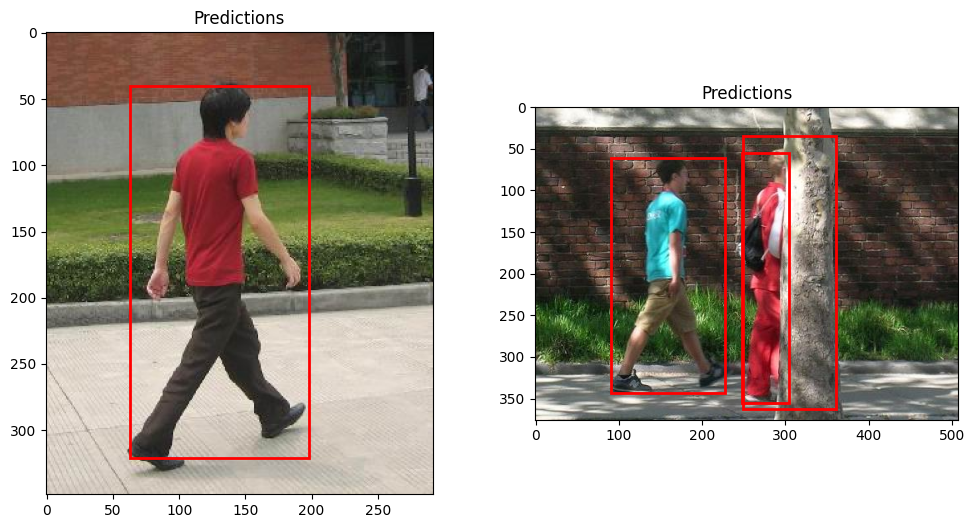

In [10]:

# Evaluate on validation set (just visualize predictions)
model.eval()
imgs, targets = next(iter(val_loader))
imgs = [img.to(device) for img in imgs]
outputs = model(imgs)

# Plot results
fig, ax = plt.subplots(1, 2, figsize=(12,6))
for i in range(2):
    img = imgs[i].permute(1,2,0).cpu().numpy()
    ax[i].imshow(img)
    for box in outputs[i]['boxes'].cpu().detach().numpy():
        x1, y1, x2, y2 = box.astype(int)
        ax[i].add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, color="red", linewidth=2))
    ax[i].set_title("Predictions")
plt.show()
